In [3]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [25]:
df = pd.read_csv("kidiq.csv")
df0 = df[df["mom_hs"] == 0]
df1 = df[df["mom_hs"] == 1]
y0 = df0["kid_score"]
y1 = df1["kid_score"]
print(f"{y1.mean()=:.2f}, {y0.mean()=:.2f}")
stats.ttest_ind(y0, y1)

y1.mean()=89.32, y0.mean()=77.55


TtestResult(statistic=np.float64(-5.068516079092328), pvalue=np.float64(5.956524110583287e-07), df=np.float64(432.0))

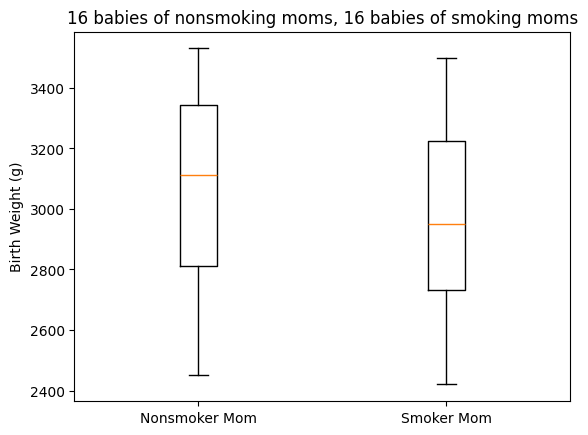

In [18]:
df = pd.read_csv("birthsmokers.csv")
y0 = df[df["Smoke"] == 0]["Wgt"]
y1 = df[df["Smoke"] == 1]["Wgt"]
plt.boxplot([y0, y1], tick_labels=["Nonsmoker Mom", "Smoker Mom"])
plt.ylabel("Birth Weight (g)")
plt.title("16 babies of nonsmoking moms, 16 babies of smoking moms")
plt.show()

In [5]:
s = np.sqrt(0.5 * (y0.std() ** 2 + y1.std() ** 2))
n = len(y0)
assert n == len(y1)

In [6]:
statistic = (y0.mean() - y1.mean()) / (s * np.sqrt(2 / n))
pvalue = 2 * stats.t.cdf(-np.abs(statistic), df=30)
print(f"{statistic=:.4f}, {pvalue=:.4f}")
print(stats.ttest_ind(y0, y1))

statistic=0.7483, pvalue=0.4601
TtestResult(statistic=np.float64(0.7482931945828962), pvalue=np.float64(0.46010984851515213), df=np.float64(30.0))


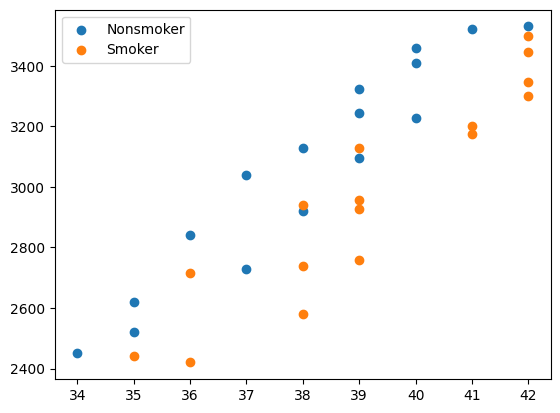

In [7]:
df0 = df[df["Smoke"] == 0]
df1 = df[df["Smoke"] == 1]
plt.scatter(df0["Gest"], df0["Wgt"], label="Nonsmoker")
plt.scatter(df1["Gest"], df1["Wgt"], label="Smoker")
plt.legend()

In [8]:
df["Const"] = 1.0
X = df[["Const", "Gest", "Smoke"]]
y = df["Wgt"]

In [9]:
model = sm.OLS(y, X)
fit = model.fit()
fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    Wgt   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.889
Method:                 Least Squares   F-statistic:                     125.4
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           5.29e-15
Time:                        15:19:41   Log-Likelihood:                -195.82
No. Observations:                  32   AIC:                             397.6
Df Residuals:                      29   BIC:                             402.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Const      -2389.5729    349.206     -6.843      0.000   -3103.779   -1675.366
Gest         143.1003      9.128     15.677      0.000     124.431     161.769
Smoke       -244.5440     41.982     -5.825      0.000    -330.406    -158.682
==============================================================================
Omnibus:                        1.946   Durbin-Watson:                   2.016
Prob(Omnibus):                  0.378   Jarque-Bera (JB):                1.162
Skew:                          -0.090   Prob(JB):                        0.559
Kurtosis:                       2.084   Cond. No.                         663.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Systolic blood pressure (SBP) among adult men with mild-to-moderate hypertension has mean 148 mm Hg and standard deviation 10 mm Hg.

For members of this population, a Propranolol reduces SBP by 12 mm Hg on average, with a standard deviation of 5 mm Hg.

For a single patient, visit-to-visit variation in SBP in the range 10-15 mm Hg.

<Axes: xlabel='pretest', ylabel='posttest'>

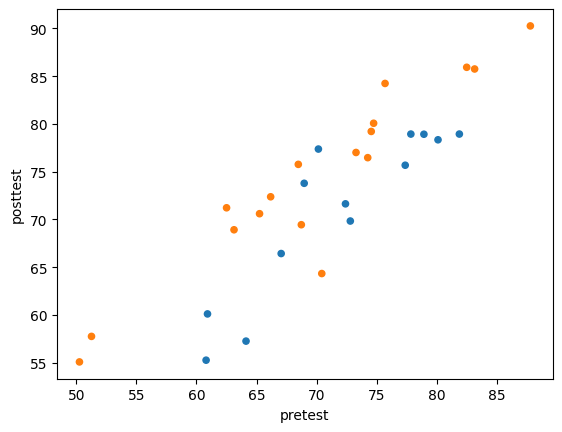

In [10]:
n = 30
effect = 4
rng = np.random.default_rng(666)
pretest = 70 + 8 * rng.normal(size=n)
group = 1 * (rng.uniform(size=n) < 0.5)
posttest = pretest + effect * group + 4 * rng.normal(size=n)
df = pd.DataFrame({"pretest": pretest, "group": group, "posttest": posttest})
c = ["C1" if x else "C0" for x in df["group"]]
df.plot.scatter("pretest", "posttest", c=c)

In [11]:
df0 = df[df["group"] == 0]
df1 = df[df["group"] == 1]

In [12]:
stats.ttest_ind(df0["posttest"], df1["posttest"])

TtestResult(statistic=np.float64(-1.0010197938243435), pvalue=np.float64(0.3253901166782126), df=np.float64(28.0))

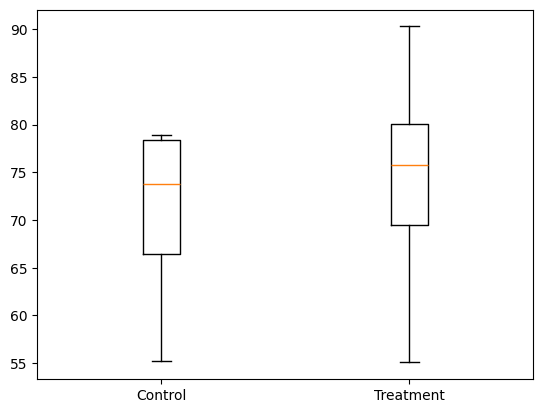

In [13]:
plt.boxplot([df0["posttest"], df1["posttest"]], tick_labels=["Control", "Treatment"])
plt.show()

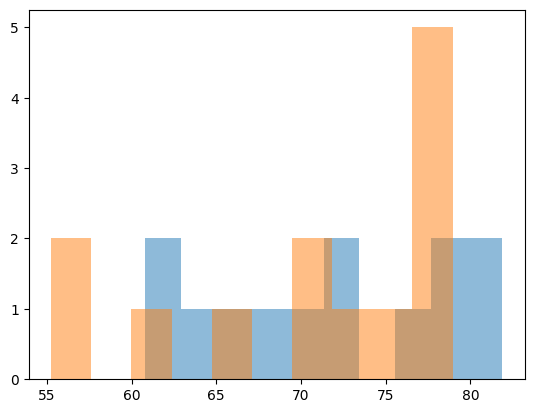

In [14]:
plt.hist(df0["pretest"], alpha=0.5, label="Control")
plt.hist(df0["posttest"], alpha=0.5, label="Treatment")
plt.show()

In [15]:
df["const"] = 1.0
X = df[["const", "pretest", "group"]]
y = df["posttest"]
model = sm.OLS(y, X)
fit = model.fit()
fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               posttest   R-squared:                       0.856
Model:                            OLS   Adj. R-squared:                  0.846
Method:                 Least Squares   F-statistic:                     80.57
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           4.15e-12
Time:                        15:19:41   Log-Likelihood:                -79.745
No. Observations:                  30   AIC:                             165.5
Df Residuals:                      27   BIC:                             169.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.5250      5.595      0.451      0.655      -8.955      14.005
pretest        0.9533      0.077     12.435      0.000       0.796       1.111
group          5.0086      1.347      3.718      0.001       2.245       7.773
==============================================================================
Omnibus:                        6.060   Durbin-Watson:                   1.460
Prob(Omnibus):                  0.048   Jarque-Bera (JB):                4.990
Skew:                          -0.556   Prob(JB):                       0.0825
Kurtosis:                       4.660   Cond. No.                         602.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

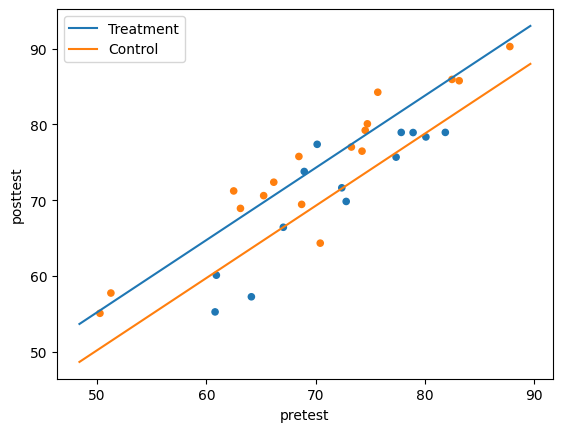

In [16]:
b = fit.params
b["const"]
df.plot.scatter("pretest", "posttest", c=c)
xmin, xmax = plt.xlim()
plt.plot(
    [xmin, xmax],
    [
        b["const"] + b["group"] + b["pretest"] * xmin,
        b["const"] + b["group"] + b["pretest"] * xmax,
    ],
    label="Treatment",
)
plt.plot(
    [xmin, xmax],
    [b["const"] + b["pretest"] * xmin, b["const"] + b["pretest"] * xmax],
    label="Control",
)
plt.legend()
plt.show()